<a href="https://colab.research.google.com/github/GulaiRandang/Data-Science_IF405_2026/blob/main/Pertemuan5_%5BAbdurrhman_AL_Asykari%5D_%5B240401010131%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape & Dtypes:
(891, 15)
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Deskripsi Statistik:
       survived  pclass     age   sibsp   parch    fare
count    891.00  891.00  714.00  891.00  891.00  891.00
mean       0.38    2.31   29.70    0.52    0.38   32.20
std        0.49    0.84   14.53    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   20.12    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   38.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33


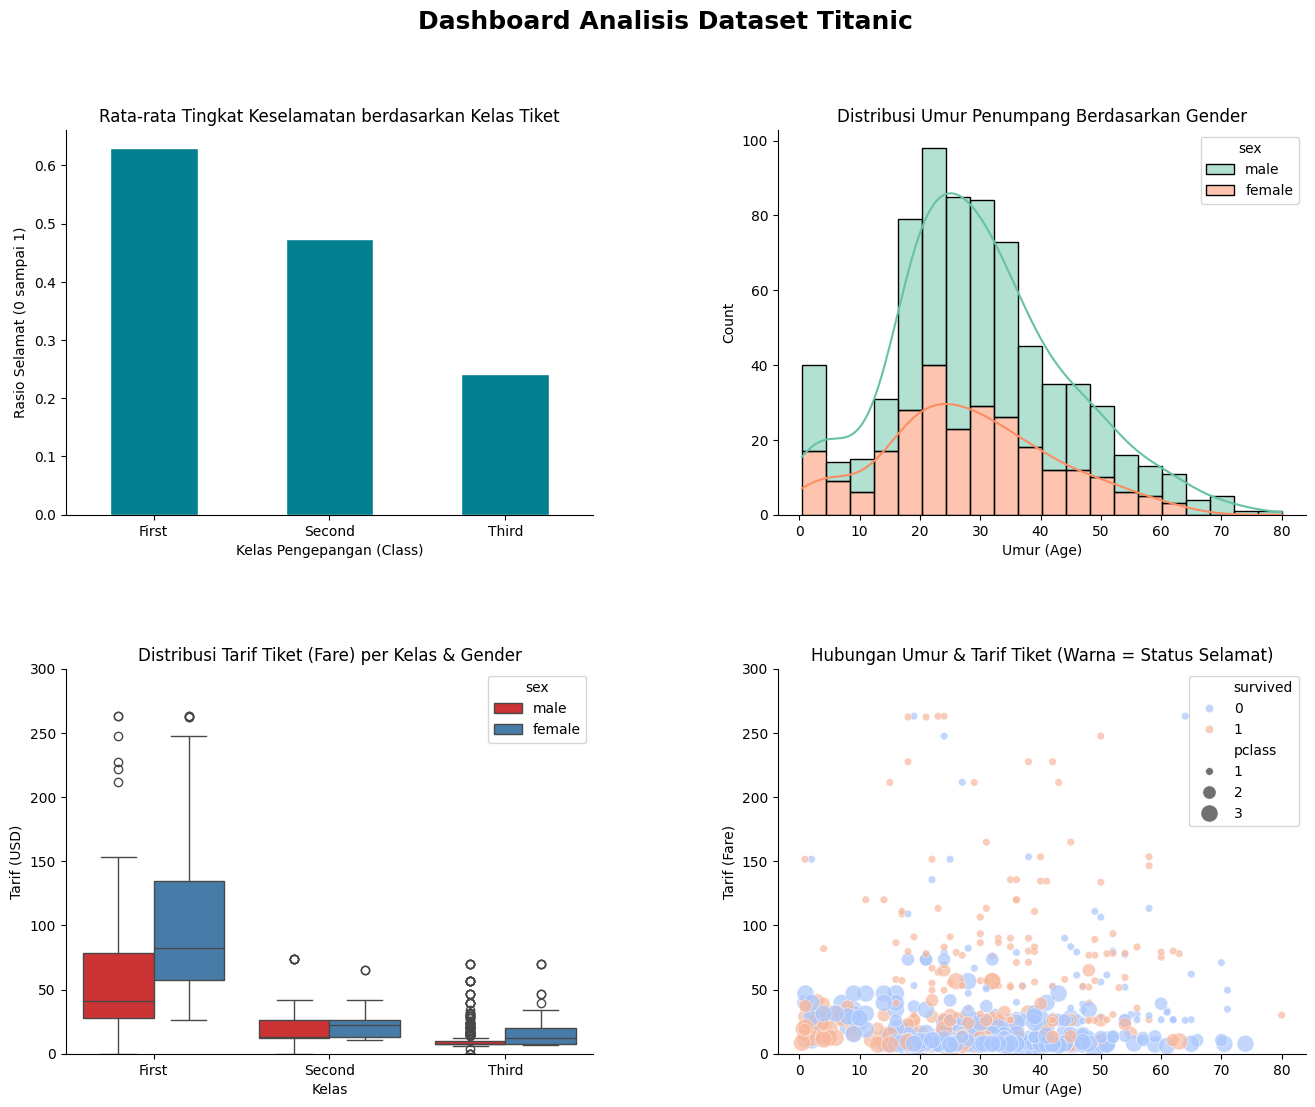

Dashboard tersimpan sebagai dashboard_titanic.png


In [7]:
# ── 0. IMPORT LIBRARIES ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('titanic')
print('Shape & Dtypes:')
print(df.shape)
print(df.dtypes)
print('\nDeskripsi Statistik:')
print(df.describe().round(2))

# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Titanic',
             fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# ── 3. GRAFIK 1: Bar Chart (Tingkat Keselamatan per Kelas) ──────────────
# Menggunakan observed=False agar aman di versi pandas terbaru
avg_survived_class = df.groupby('class', observed=False)['survived'].mean()
avg_survived_class.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Tingkat Keselamatan berdasarkan Kelas Tiket')
ax1.set_xlabel('Kelas Pengepangan (Class)'); ax1.set_ylabel('Rasio Selamat (0 sampai 1)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ── 4. GRAFIK 2: Histogram + KDE (Distribusi Umur Berdasarkan Gender) ──
sns.histplot(data=df, x='age', hue='sex', kde=True, palette='Set2', ax=ax2, multiple='stack')
ax2.set_title('Distribusi Umur Penumpang Berdasarkan Gender')
ax2.set_xlabel('Umur (Age)')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot (Distribusi Tarif Tiket per Kelas & Gender) ───
sns.boxplot(data=df, x='class', y='fare', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tarif Tiket (Fare) per Kelas & Gender')
ax3.set_xlabel('Kelas'); ax3.set_ylabel('Tarif (USD)')
ax3.set_ylim(0, 300) # Membatasi sumbu Y agar tidak terganggu outlier ekstrem
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot (Hubungan Umur & Tarif Tiket) ────────────
sns.scatterplot(data=df, x='age', y='fare', hue='survived', size='pclass', sizes=(30,150), palette='coolwarm', alpha=0.7, ax=ax4)
ax4.set_title('Hubungan Umur & Tarif Tiket (Warna = Status Selamat)')
ax4.set_xlabel('Umur (Age)'); ax4.set_ylabel('Tarif (Fare)')
ax4.set_ylim(0, 300)
ax4.spines[['top','right']].set_visible(False)

# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_titanic.png')

